# Data Understanding

**Project:** Vancouver Property Value Prediction
**Notebook goal:** First look at the Property Tax Report dataset from the City of Vancouver Open Data Portal. Understand its structure, size, types, and identify the target variable and candidate features for the ML model.

**Data source:** https://opendata.vancouver.ca/explore/dataset/property-tax-report/

**Author:** Rafael Carrillo Mirabal

In [2]:
# Core libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
pd.set_option('display.max_columns', None)   # Show all columns when displaying DataFrames
pd.set_option('display.width', 200)          # Wider display
sns.set_style('whitegrid')                   # Nicer default style for plots

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


## 1. Load the dataset

The dataset is in Parquet format (~134 MB on disk, ~691 MB in memory).
Parquet is the industry standard for columnar storage — fast to load, preserves data types, and compresses well.

In [3]:
# Load the parquet file
# Note: the file is in data/raw/ and is NOT tracked in git (see .gitignore)
df = pd.read_parquet("../data/raw/property_tax_report.parquet")

print(f"✅ Dataset loaded")
print(f"   Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"   Memory: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

✅ Dataset loaded
   Shape: 1,552,663 rows × 30 columns
   Memory: 690.7 MB


## 2. First glance: structure and types

Let's see the columns, data types, and a sample of the data.

In [4]:
# Show the first 5 rows
df.head()

,pid,legal_type,folio,land_coordinate,zoning_district,zoning_classification,lot,plan,block,district_lot,from_civic_number,to_civic_number,street_name,property_postal_code,narrative_legal_line1,narrative_legal_line2,narrative_legal_line3,narrative_legal_line4,narrative_legal_line5,current_land_value,current_improvement_value,tax_assessment_year,previous_land_value,previous_improvement_value,year_built,big_improvement_year,tax_levy,neighbourhood_code,report_year,note
0,013-172-549,LAND,830212830000,83021283,R1-1,Residential Inclusive,4,VAP3089,A,327,NaN,961,MARINE DR SE,V5X 2V2,"LOT 4, BLOCK A, PLAN VAP3089, DISTR","ICT LOT 327, GROUP 1, NEW WESTMINST","ER LAND DISTRICT, EXC PT IN EXPL PL","6777, OF LOTS 5 TO 8",NaN,1250000.0,767000.0,2023,1161192.0,799000.0,2017,2017,6678.66,017,2023,NaN
1,030-022-843,STRATA,320718950602,32071895,CD-1 (545),Comprehensive Development,602,EPS3434,6,36,3203,5665,BOUNDARY RD,V5R 0E4,LOT 602 BLOCK 6 PLAN EPS3434 DIS,"TRICT LOT 36 NWD GROUP 1, TOGETHER",WITH AN INTEREST IN THE COMMON PRO,PERTY IN PROPORTION TO THE UNIT ENT,ITLEMENT OF THE STRATA LOT AS SHOWN,566000.0,322000.0,2023,507000.0,306000.0,2016,2016,2469.26,023,2023,NaN
2,027-537-978,STRATA,592118060076,59211806,DD,Comprehensive Development,76,BCS2936,NaN,185,2504,1188,PENDER ST W,V6E 0A2,LOT 76 PLAN BCS2936 DISTRICT LOT,185 NWD GROUP 1.,NaN,NaN,NaN,793000.0,427000.0,2023,800000.0,415000.0,2008,2008,3392.44,026,2023,NaN
3,028-763-017,STRATA,670026450025,67002645,C-2,Commercial,25,BCS4338,148,540,401,4355,10TH AVE W,V6R 2H6,LOT 25 BLOCK 148 PLAN BCS4338 DI,"STRICT LOT 540 NWD GROUP 1, TOGETH",ER WITH AN INTEREST IN THE COMMON P,ROPERTY IN PROPORTION TO THE UNIT E,NTITLEMENT OF THE STRATA LOT AS SHO,1157477.0,347000.0,2023,1009000.0,311000.0,2012,2012,4183.51,001,2023,NaN
4,028-763-050,STRATA,670026450029,67002645,C-2,Commercial,29,BCS4338,148,540,405,4355,10TH AVE W,V6R 2H6,LOT 29 BLOCK 148 PLAN BCS4338 DI,"STRICT LOT 540 NWD GROUP 1, TOGETH",ER WITH AN INTEREST IN THE COMMON P,ROPERTY IN PROPORTION TO THE UNIT E,NTITLEMENT OF THE STRATA LOT AS SHO,493000.0,182000.0,2023,427000.0,175000.0,2012,2012,1876.98,001,2023,NaN


In [5]:
# Data types and non-null counts per column
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1552663 entries, 0 to 1552662
Data columns (total 30 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   pid                         1548795 non-null  str    
 1   legal_type                  1552663 non-null  str    
 2   folio                       1552663 non-null  str    
 3   land_coordinate             1552663 non-null  str    
 4   zoning_district             1552621 non-null  str    
 5   zoning_classification       1546966 non-null  str    
 6   lot                         1542004 non-null  str    
 7   plan                        1551134 non-null  str    
 8   block                       620147 non-null   str    
 9   district_lot                1477103 non-null  str    
 10  from_civic_number           784487 non-null   str    
 11  to_civic_number             1548722 non-null  str    
 12  street_name                 1551613 non-null  str    
 13  property

## 3. Numerical summary

Statistical overview of the numeric columns.

In [6]:
# Summary statistics for numeric columns
df.describe()

,current_land_value,current_improvement_value,previous_land_value,previous_improvement_value,tax_levy
count,1.526086e+06,1.526086e+06,1.510043e+06,1.510043e+06,1.528052e+06
mean,1.767317e+06,4.747098e+05,1.792276e+06,4.532121e+05,9.649043e+03
std,1.013329e+07,5.119859e+06,1.028543e+07,4.776190e+06,6.609286e+04
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.160000e+05,1.050000e+05,5.130000e+05,1.030000e+05,2.105870e+03
50%,1.010000e+06,1.980000e+05,1.013000e+06,1.960000e+05,4.254470e+03
75%,1.761000e+06,3.300000e+05,1.744000e+06,3.240000e+05,8.127142e+03
max,3.637869e+09,1.136633e+09,3.637869e+09,9.346550e+08,9.760300e+06


## 4. Missing values analysis

How clean is the data? Which columns have nulls and how many?

In [7]:
# Count nulls per column, show only columns with at least one null
nulls = df.isnull().sum()
nulls_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'null_count': nulls,
    'null_pct': nulls_pct
}).sort_values('null_count', ascending=False)

# Show only columns with nulls
missing_df[missing_df['null_count'] > 0]

,null_count,null_pct
note,1551507,99.93
narrative_legal_line5,1047866,67.49
narrative_legal_line4,1003419,64.63
block,932516,60.06
from_civic_number,768176,49.47
narrative_legal_line3,445325,28.68
district_lot,75560,4.87
big_improvement_year,58615,3.78
year_built,58615,3.78
previous_improvement_value,42620,2.74


## 5. Temporal coverage

The dataset spans multiple years. Let's confirm.

report_year
2020    214803
2021    217802
2022    218674
2023    222197
2024    224743
2025    226360
2026    228084
Name: count, dtype: int64


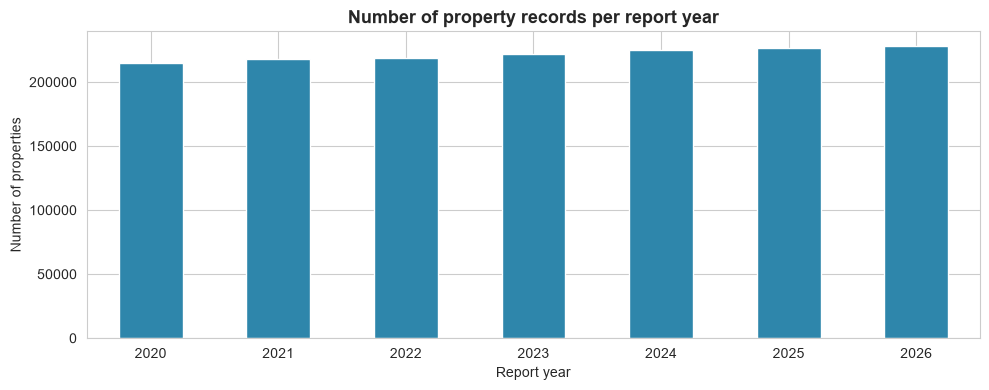

In [8]:
# Distribution of records per report year
year_counts = df['report_year'].value_counts().sort_index()
print(year_counts)

# Visualize
fig, ax = plt.subplots(figsize=(10, 4))
year_counts.plot(kind='bar', ax=ax, color='#2E86AB')
ax.set_title('Number of property records per report year', fontsize=13, fontweight='bold')
ax.set_xlabel('Report year')
ax.set_ylabel('Number of properties')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Target variable identification

The goal of the model is to predict property value. The relevant columns are:

- `current_land_value`: value of the land (CAD)
- `current_improvement_value`: value of the building/improvements on the land (CAD)

Total property value = land value + improvement value.

Let's create a quick `total_value` column for inspection (we will formalize feature engineering in the preprocessing notebook).

In [9]:
# Quick total value column (just for exploration)
df['total_value'] = df['current_land_value'] + df['current_improvement_value']

# Stats on the target
print("Total property value (CAD) — descriptive stats:")
print(df['total_value'].describe().apply(lambda x: f"{x:,.0f}"))

Total property value (CAD) — descriptive stats:
count        1,526,086
mean         2,242,027
std         12,770,474
min                  0
25%            704,000
50%          1,255,200
75%          2,060,000
max      3,648,569,000
Name: total_value, dtype: str


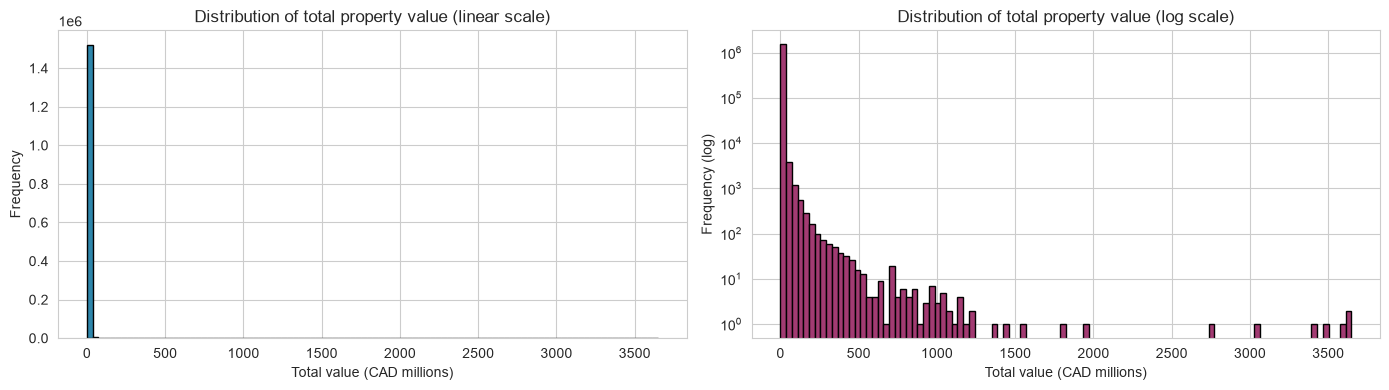

In [10]:
# Visualize the distribution of total_value
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram (linear scale)
axes[0].hist(df['total_value'] / 1e6, bins=100, color='#2E86AB', edgecolor='black')
axes[0].set_title('Distribution of total property value (linear scale)')
axes[0].set_xlabel('Total value (CAD millions)')
axes[0].set_ylabel('Frequency')

# Histogram (log scale on Y) — better for skewed data
axes[1].hist(df['total_value'] / 1e6, bins=100, color='#A23B72', edgecolor='black')
axes[1].set_yscale('log')
axes[1].set_title('Distribution of total property value (log scale)')
axes[1].set_xlabel('Total value (CAD millions)')
axes[1].set_ylabel('Frequency (log)')

plt.tight_layout()
plt.show()

## 7. Initial observations

Findings from this first exploration:

1. **Dataset is large and clean.** 1.55M records across 7 years (2020–2026), 30 columns.
2. **Target variable is identified.** `current_land_value + current_improvement_value` = total property value.
3. **Target is highly skewed.** Long-tail of expensive properties. Will need log-transform or outlier handling.
4. **Some type conversions needed.** `year_built`, `report_year`, `tax_assessment_year`, `big_improvement_year` are strings but represent years.
5. **High-null columns to drop:** `note` (99.9% null), `narrative_legal_line3-5`, `block`, `from_civic_number`.
6. **Critical features with manageable nulls:** `year_built` has ~3.7% nulls → impute or filter.
7. **Strong feature candidates:** `zoning_classification`, `neighbourhood_code`, `legal_type`, `year_built`, `street_name`, `tax_levy`.

**Next notebook:** `01_eda.ipynb` — deep exploratory data analysis with statistical and visual analysis per feature.